# ML05: State Life Expectancy Prediction

Your goal is to build a model predicting state life expectancy based on various socio-economic factors. You will use a dataset containing information about different states, including demographics, health care access, and economic indicators.

In [ ]:
# We use statsmodels as a nicer version of OLS.
#%pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
# Load your data and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = 'statelife.csv'
df_raw = pd.read_csv(path, skiprows=3)

# limit columns to make problem more manageable.
df_raw = df_raw[['statename',  'life_expectancy', 'total_guns', 'population_in_2021']]
#df_raw = df_raw[['statename', 'life_expectancy', 'smoking_rate', 'democratic_votes_rate', 'republican_votes_rate', 'total_guns', 'population_in_2021', 'religious_adults_rate']]
#df_raw = df_raw[['statename', 'religious_adults_rate', 'democratic_votes_rate', 'republican_votes_rate', 'life_expectancy', 'people_in_poverty', 'smoking_rate', 'total_guns', 'population_in_2021', 'median_age']]


number_columns = df_raw.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print("DataFrame dtypes:")
print(df_raw.dtypes)
df_raw.describe()

df_raw.head()

DataFrame dtypes:
statename                 str
life_expectancy       float64
total_guns            float64
population_in_2021    float64
dtype: object


/var/folders/w6/p7gv5g6166vbk07p2pwdxjqr0000gp/T/ipykernel_99466/1337095503.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()


,statename,life_expectancy,total_guns,population_in_2021
0,Alabama,73.2,161641.0,5048733.0
1,Alaska,76.6,15824.0,735707.0
2,Arizona,76.3,179738.0,7227450.0
3,Arkansas,73.8,79841.0,3021085.0
4,California,79.0,344622.0,39766650.0


# Step 1: Data Quality

Examine fields for data issues. Look at each field, and do the following:

- Identify numeric fields that have extreme values. However, since we only have a few rows, we will generally note remove extreme values unless they are a significant error. In that case, you 
can replace that value with a reasonable figure. 
- Identify rows that are problematic. If a row has multiple missing values, you may need to remove it.
- Identify fields that are redundant. This is particularly true for fields that are combinations of other fields, or fields that are the inverse of other fields.
- Remove fields that do not have a clear link to the outcome variable. If a field is not likely to influence life expectancy, consider removing it. For this dataset, remove marriage rates.
- Convert absolute numbers into rates. For example, convert number of people in poverty into a rate of people in poverty by dividing by total population.
- Remove text fields that you can not use in a model



In [ ]:
# Data Cleanup

# Step 0: Create a new df to work with 
df = df_raw.copy()
old_record_count = df.shape[0]

# Step 1: Feature creation
df = df.assign(
    guns_pct = df['total_guns'] / df['population_in_2021']
)

# find the 2nd highst guns_pct value 
guns_pct_threshold = df['guns_pct'].nlargest(2).iloc[-1]
df = df.assign(
    guns_pct = np.where(df['guns_pct'] > guns_pct_threshold, guns_pct_threshold, df['guns_pct'])
)

# Step 2: Remove outliers

# Step 3: Remove columns with duplicate information or not useful for prediction
df = df.dropna()

df = df.drop(columns=['total_guns', 'population_in_2021'])

print(f"Removed {old_record_count - df.shape[0]} outlier records")

df.head()

Removed 1 outlier records


,statename,life_expectancy,guns_pct
0,Alabama,73.2,0.032016
1,Alaska,76.6,0.021509
2,Arizona,76.3,0.024869
3,Arkansas,73.8,0.026428
4,California,79.0,0.008666


# Step 2: Visualize data

Use a pairplot and histograms to visualize the data.

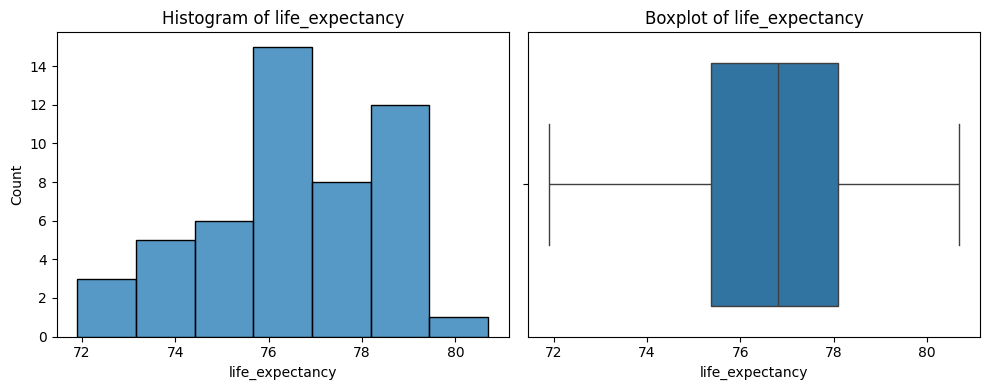

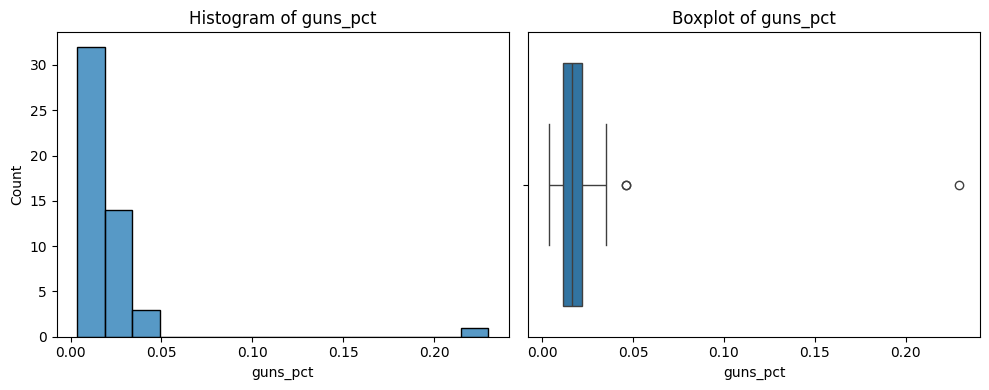

In [16]:
# Plot each numeric variable

number_columns = df.select_dtypes(include=['number']).columns.tolist()
text_columns = df.select_dtypes(include=['str', 'category']).columns.tolist()

for col in number_columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


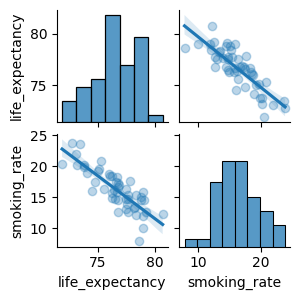

In [5]:
# Plot a pairs printout of each of the numeric variables
sns.pairplot(df, kind='reg', height=1.5, plot_kws={'scatter_kws': {'alpha': 0.3}})
plt.show()

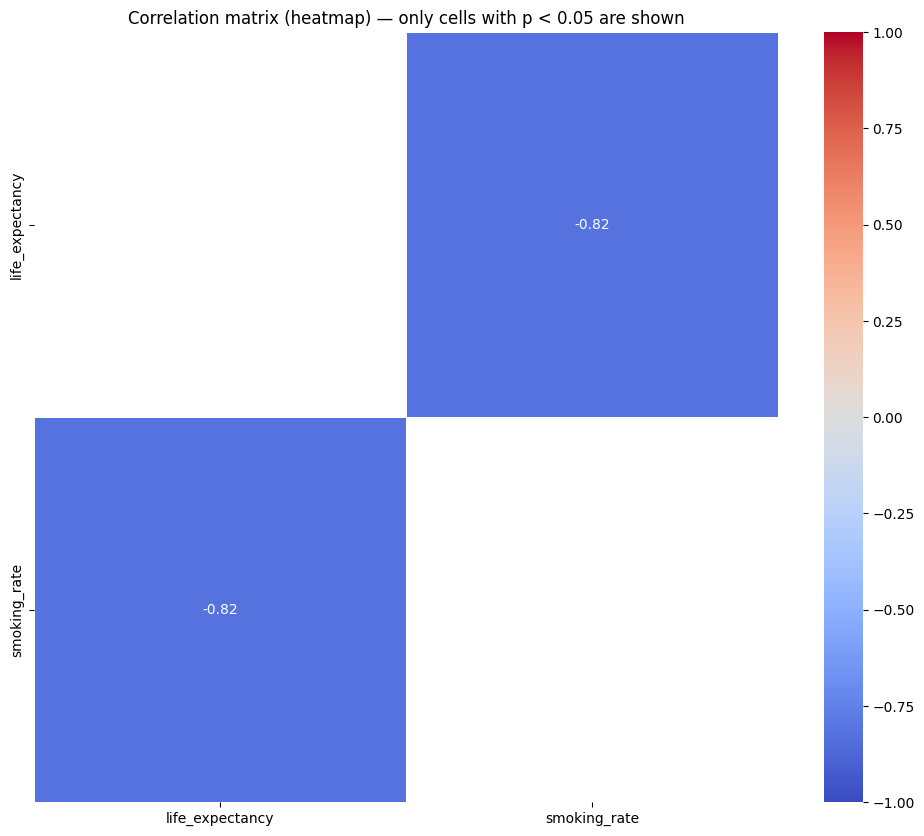

In [6]:
import statsmodels.api as sm
import numpy as np

# Round printout of numbers to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Ensure we have the numeric column list (recompute to be safe)
number_columns = df.select_dtypes(include=['number']).columns.tolist()

# Print correlations
corr_matrix = df[number_columns].corr()


# Compute pairwise p-values using OLS (returns p-value for the slope)
def pairwise_pvalues(df_nums):
    cols = df_nums.columns
    pvals = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            x = df_nums.iloc[:, i].dropna()
            y = df_nums.iloc[:, j].dropna()
            common_index = x.index.intersection(y.index)
            if len(common_index) < 2:
                p = np.nan
            else:
                try:
                    model = sm.OLS(x.loc[common_index], sm.add_constant(y.loc[common_index])).fit()
                    # use iloc to access by position to avoid FutureWarning when Series has integer labels
                    p = model.pvalues.iloc[1] if len(model.pvalues) > 1 else np.nan
                except Exception:
                    p = np.nan
            pvals.iat[i, j] = p
            pvals.iat[j, i] = p
    return pvals

p_values = pairwise_pvalues(df[number_columns])

# Build a mask where p-values are >= 0.05 (not significant) - these will be hidden
mask_non_significant = p_values >= 0.05
# Ensure diagonal is shown (p-values on diagonal may be NaN); don't mask the diagonal
#np.fill_diagonal(mask_non_significant.values, False)

# Plot correlation heatmap but hide cells that are NOT significant (p >= 0.05)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask_non_significant, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation matrix (heatmap) — only cells with p < 0.05 are shown')
plt.show()



# Step 3: Build a simple linear regression model

Key items:

- Residuals = errors in each row between actual & predicted
- Standard Error = the squared difference between the predicted and actual values. 
- Coefficients:
  - Estimate: value of the change in input to output
  - Standard Error: averages squared diff between prediction / actual
  - p Value: probability of the estimate being a result of random chance
- Residual standard error: the overall avg difference between actual
    and predicted for the entire model.
  - Adj R^2,  the % of variation explained by the model

In [6]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

number_columns = df.select_dtypes(include=['number']).columns.tolist()
print(number_columns)

# Get variables for prediction. Basic (poor) model
X = df[number_columns].drop(columns=['life_expectancy'])  

y = df['life_expectancy']

# Fit the model
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
predictions = model.predict(X)
print(model.summary())



['life_expectancy', 'smoking_rate']
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     102.0
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.84e-13
Time:                        15:12:05   Log-Likelihood:                -75.763
No. Observations:                  50   AIC:                             155.5
Df Residuals:                      48   BIC:                             159.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const       

RMSE: 1.1011218714644113
R²: 0.6799521233720602


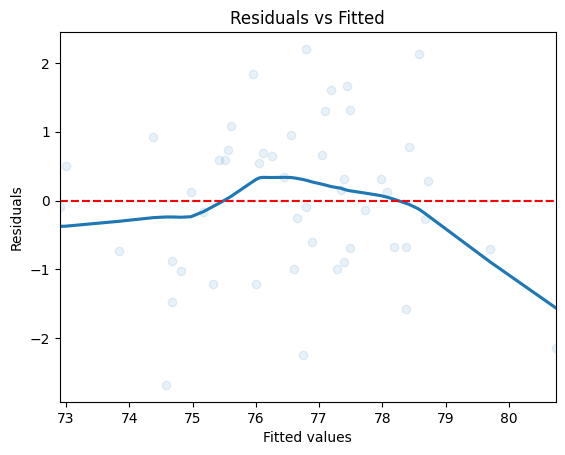

In [7]:
resid = model.resid
fitted = model.fittedvalues
rmse_value = np.sqrt(np.mean(resid**2))
print(f"RMSE: {rmse_value}")
r2_value = model.rsquared
print(f"R²: {r2_value}")

# Plot resduals
sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.axhline(0, color='red', linestyle='--')
plt.show()